# CSE440: NLP II — Lab Project
## Multi-Class News Topic Classification: A Comparative Analysis

**Group 3** — Imtiaz Hossain (23101137), Md Saidul Islam Apu (21301668)

---

This notebook benchmarks **9 model–representation combinations** across **3 preprocessing variants** (27 total runs) on a 4-class news-headline corpus.

| Section | Content |
|---|---|
| 1 | Setup, GPU check, imports |
| 2 | Load data, label encoding, train/val split |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Three preprocessing pipelines (none / extreme / optimum) |
| 5 | Word representations (TF-IDF, Skip-gram) |
| 6 | Models — Logistic Regression, Deep NN, RNN/GRU/LSTM (+ Bi), BERT-Base |
| 7 | Evaluation, comparison tables, plots |
| 8 | Conclusion |

> **Hardware note:** All neural networks run on PyTorch + CUDA (RTX 3070, 8 GB). TensorFlow ≥ 2.11 dropped native-Windows GPU support, so PyTorch is used throughout.

## 1. Setup & GPU Verification

In [1]:
import os, re, json, time, random, warnings, gc
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

import gensim
from gensim.models import Word2Vec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2))
print("Using device:", DEVICE)

PyTorch: 2.7.1+cu118
CUDA available: True
Device: NVIDIA GeForce RTX 3070
VRAM (GB): 8.59
Using device: cuda


In [2]:
# NLTK downloads (one-time)
for pkg in ["stopwords", "punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print("nltk download failed for", pkg, e)
print("NLTK assets ready.")

NLTK assets ready.


In [3]:
# Project paths
ROOT = Path.cwd()
TRAIN_CSV = ROOT / "Training_data_3.csv"
TEST_CSV  = ROOT / "Test_data.csv"
ART = ROOT / "artifacts"; ART.mkdir(exist_ok=True)
PLOTS = ART / "plots";   PLOTS.mkdir(exist_ok=True)

assert TRAIN_CSV.exists(), f"Missing {TRAIN_CSV}"
assert TEST_CSV.exists(),  f"Missing {TEST_CSV}"
print("Train CSV:", TRAIN_CSV)
print("Test  CSV:", TEST_CSV)

Train CSV: C:\Users\imtia\OneDrive\Desktop\CSE440\LAB\NEW PROJECT\Training_data_3.csv
Test  CSV: C:\Users\imtia\OneDrive\Desktop\CSE440\LAB\NEW PROJECT\Test_data.csv


## 2. Load Data, Label Encoding, Train/Val Split

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
print("Train:", train_df.shape, "Test:", test_df.shape)
print("Columns:", train_df.columns.tolist())
train_df.head(3)

Train: (102002, 2) Test: (12000, 2)
Columns: ['News Headline', 'News Topic']


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Googl...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> UA FO...,Sports
2,<html> <body> News Headlines:\n <br> <b> Tul I...,Science and Technology


In [5]:
LABELS = sorted(train_df["News Topic"].unique().tolist())
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
NUM_CLASSES = len(LABELS)

train_df["label"] = train_df["News Topic"].map(LABEL2ID)
test_df["label"]  = test_df["News Topic"].map(LABEL2ID)
print("Label mapping:", LABEL2ID)

# Stratified train/val split (validation is used for tuning; test stays untouched)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    train_df["News Headline"].values, train_df["label"].values,
    test_size=0.2, random_state=SEED, stratify=train_df["label"].values)
X_test_raw, y_test = test_df["News Headline"].values, test_df["label"].values

print("Train:", len(X_train_raw), "Val:", len(X_val_raw), "Test:", len(X_test_raw))

Label mapping: {'Business': 0, 'Science and Technology': 1, 'Sports': 2, 'World News': 3}
Train: 81601 Val: 20401 Test: 12000


## 3. Exploratory Data Analysis (EDA)

Several visualizations to guide preprocessing decisions.

### 3.1 Class distribution (train vs test)

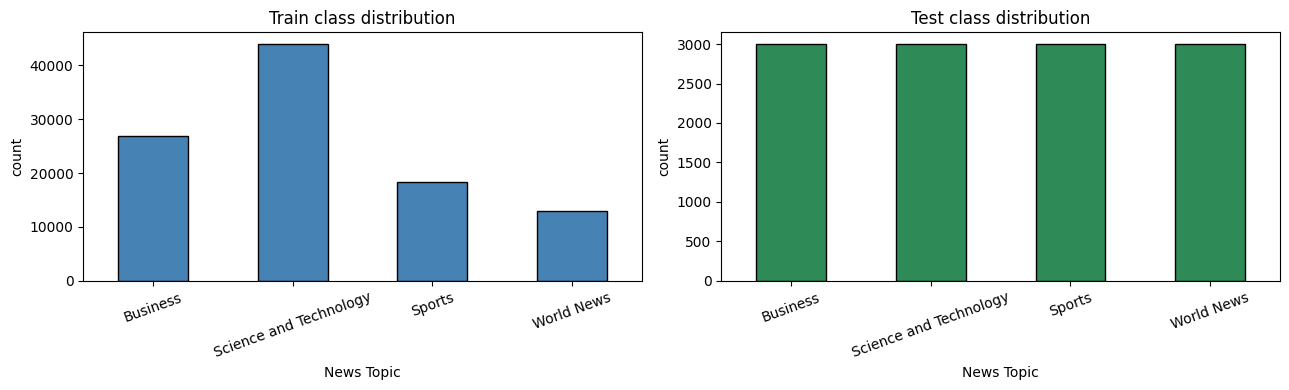

News Topic
Science and Technology    43961
Business                  26834
Sports                    18287
World News                12920
Name: count, dtype: int64

Imbalance ratio (max/min): 3.4


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_df["News Topic"].value_counts().reindex(LABELS).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Train class distribution"); axes[0].set_ylabel("count"); axes[0].tick_params(axis='x', rotation=20)
test_df["News Topic"].value_counts().reindex(LABELS).plot(
    kind="bar", ax=axes[1], color="seagreen", edgecolor="black")
axes[1].set_title("Test class distribution");  axes[1].set_ylabel("count"); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig(PLOTS / "01_class_dist.png", dpi=120); plt.show()

print(train_df["News Topic"].value_counts())
print()
print("Imbalance ratio (max/min):",
      round(train_df["News Topic"].value_counts().max() /
            train_df["News Topic"].value_counts().min(), 2))

**Insight:** Training set is imbalanced — Sci&Tech is ~3.4× the smallest class (World News). Test set is perfectly balanced (3,000 each). We must use `class_weight="balanced"` for ML and a class-weight tensor for the PyTorch loss.

### 3.2 Headline length distributions

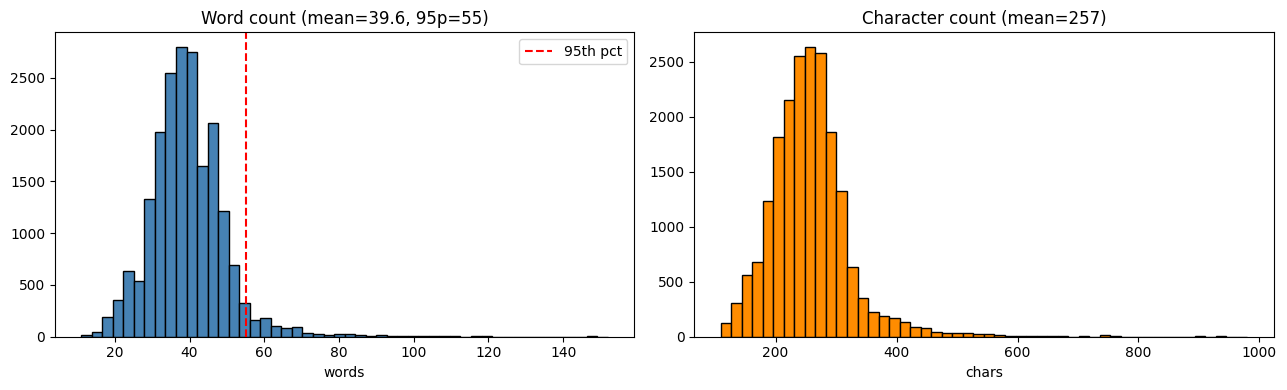

In [7]:
def strip_html_quick(t):
    return BeautifulSoup(str(t), "html.parser").get_text(" ").strip()

# Use a sample for speed when computing length stats
sample_idx = np.random.RandomState(SEED).choice(len(train_df), size=20000, replace=False)
sample_clean = pd.Series(train_df["News Headline"].iloc[sample_idx]).apply(strip_html_quick)
sample_labels = train_df["News Topic"].iloc[sample_idx].values

len_words = sample_clean.str.split().str.len()
len_chars = sample_clean.str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(len_words, bins=50, color="steelblue", edgecolor="black")
axes[0].axvline(len_words.quantile(0.95), color="red", linestyle="--", label="95th pct")
axes[0].set_title(f"Word count (mean={len_words.mean():.1f}, 95p={len_words.quantile(0.95):.0f})")
axes[0].set_xlabel("words"); axes[0].legend()
axes[1].hist(len_chars, bins=50, color="darkorange", edgecolor="black")
axes[1].set_title(f"Character count (mean={len_chars.mean():.0f})")
axes[1].set_xlabel("chars")
plt.tight_layout(); plt.savefig(PLOTS / "02_length_hist.png", dpi=120); plt.show()

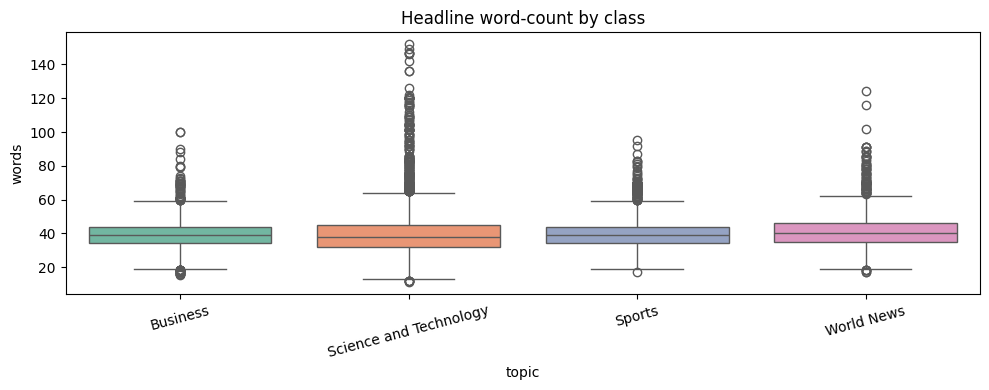

In [8]:
df_len = pd.DataFrame({"len": len_words, "topic": sample_labels})
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_len, x="topic", y="len", order=LABELS, palette="Set2")
plt.title("Headline word-count by class"); plt.ylabel("words"); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig(PLOTS / "03_length_box.png", dpi=120); plt.show()

**Insight:** Word counts are tightly distributed around 35–45 with a 95th percentile of ~57 words — `max_sequence_length = 80` will cover virtually all examples without truncation, and shorter sequences mean cheaper RNN/BERT runs.

### 3.3 HTML-tag prevalence

In [9]:
html_counts = train_df["News Headline"].str.count(r"<[^>]+>")
print("Average HTML tags per headline:", round(html_counts.mean(), 2))
print("Headlines with ≥1 tag:", (html_counts >= 1).mean()*100, "%")
print("\nRaw sample:\n", train_df["News Headline"].iloc[0][:300])

Average HTML tags per headline: 7.0
Headlines with ≥1 tag: 100.0 %

Raw sample:
 <html> <body> News Headlines:
 <br> <b> Google Browser May Be Reality Google Browser May Become Reality\\There has been much fanfare in the Mozilla fan camps about the possibility of Google using Mozilla browser technology to produce a GBrowser - the Google Browser. Over the past two weeks, the news


**Insight:** Every headline carries the same `<html><body>...<br><b>...</b><br>` wrapper. Stripping HTML in the *optimum* and *extreme* variants is essential — leaving it in (the *raw* baseline) will inflate vocabulary with `<html>`, `<br>`, etc.

### 3.4 Top words per class

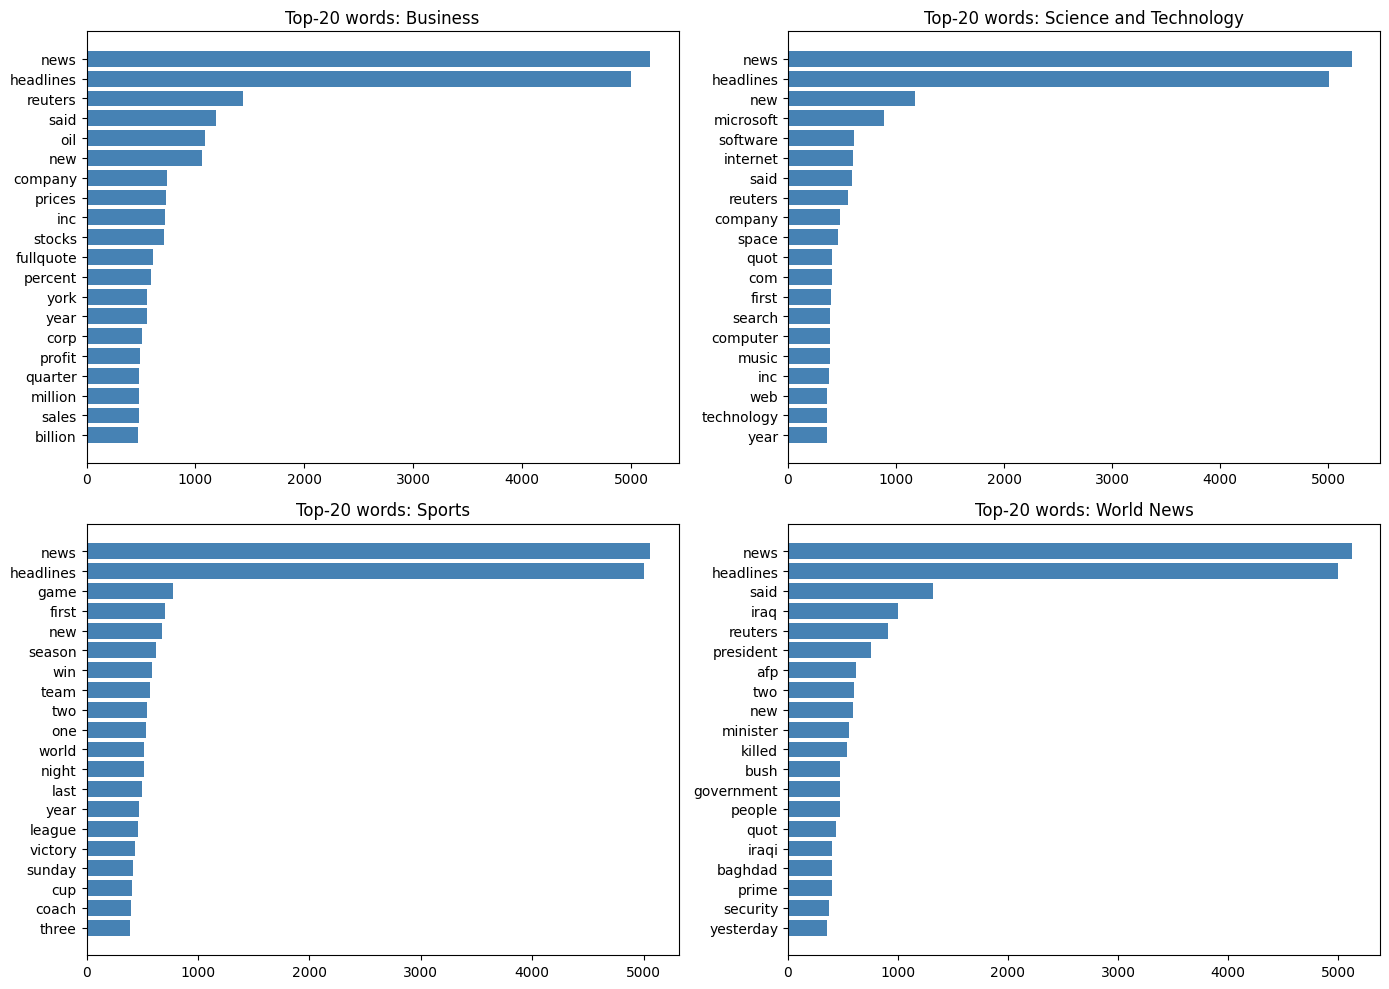

In [10]:
basic_sw = set(stopwords.words("english"))
def basic_clean(t):
    t = strip_html_quick(t).lower()
    t = re.sub(r"[^a-z\s]", " ", t)
    return [w for w in t.split() if w not in basic_sw and len(w) > 2]

per_class_top = {}
for topic in LABELS:
    docs = train_df.loc[train_df["News Topic"] == topic, "News Headline"].sample(
        min(5000, (train_df["News Topic"] == topic).sum()), random_state=SEED)
    counter = Counter()
    for t in docs:
        counter.update(basic_clean(t))
    per_class_top[topic] = counter.most_common(20)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, topic in zip(axes.ravel(), LABELS):
    items = per_class_top[topic]
    ws, cs = zip(*items)
    ax.barh(ws[::-1], cs[::-1], color="steelblue")
    ax.set_title(f"Top-20 words: {topic}")
plt.tight_layout(); plt.savefig(PLOTS / "04_top_words.png", dpi=120); plt.show()

### 3.5 Word clouds per class

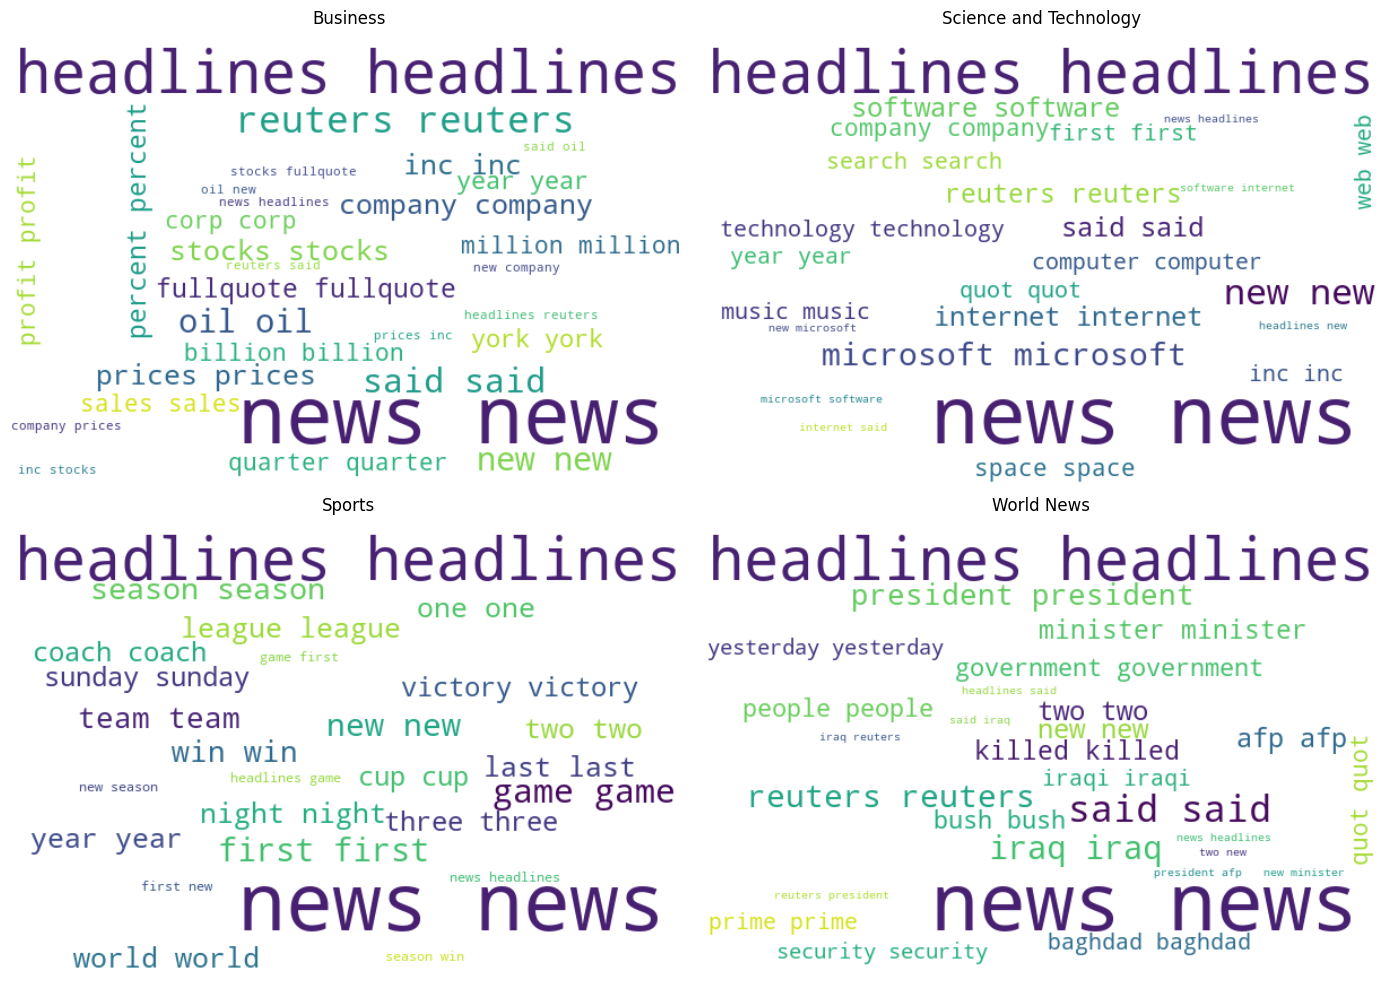

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, topic in zip(axes.ravel(), LABELS):
    text_blob = " ".join(w for w, _ in per_class_top[topic])
    bigger = " ".join((" ".join([w]*c)) for w, c in per_class_top[topic])
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", random_state=SEED).generate(bigger)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(topic)
plt.tight_layout(); plt.savefig(PLOTS / "05_wordclouds.png", dpi=120); plt.show()

**Insight:** Class-discriminative tokens emerge clearly — *Sports* ≈ {game, team, season, win}; *Business* ≈ {percent, oil, prices, stocks}; *Sci&Tech* ≈ {software, microsoft, internet}; *World News* ≈ {iraq, killed, government, minister}. The vocabulary overlap is moderate, suggesting all four classes are learnable.

### 3.6 Vocabulary statistics & OOV preview

In [12]:
def vocab_size(series):
    counter = Counter()
    for t in series:
        counter.update(t.split())
    return len(counter)

raw_sample = pd.Series(train_df["News Headline"].iloc[sample_idx])
print("Raw vocab size (incl. HTML):", vocab_size(raw_sample))
print("Cleaned vocab size:", vocab_size(sample_clean))

Raw vocab size (incl. HTML): 69678
Cleaned vocab size: 69673


### 3.7 Bigram analysis (top per class)

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

bigrams_per_class = {}
for topic in LABELS:
    docs = train_df.loc[train_df["News Topic"] == topic, "News Headline"].sample(
        min(3000, (train_df["News Topic"] == topic).sum()), random_state=SEED)
    docs_clean = docs.apply(lambda t: " ".join(basic_clean(t)))
    cv = CountVectorizer(ngram_range=(2, 2), max_features=15)
    cv.fit(docs_clean)
    counts = np.asarray(cv.transform(docs_clean).sum(axis=0)).ravel()
    pairs = sorted(zip(cv.get_feature_names_out(), counts), key=lambda x: -x[1])
    bigrams_per_class[topic] = pairs

print("Top bigrams per class:")
for k, v in bigrams_per_class.items():
    print(f"  {k}: {[w for w,_ in v]}")

Top bigrams per class:
  Business: ['news headlines', 'new york', 'oil prices', 'href http', 'http www', 'aspx ticker', 'com fullquote', 'fullquote aspx', 'investor reuters', 'quickinfo fullquote', 'reuters com', 'stocks quickinfo', 'target stocks', 'www investor', 'york reuters']
  Science and Technology: ['news headlines', 'headlines microsoft', 'reuters reuters', 'open source', 'search engine', 'microsoft corp', 'headlines ibm', 'operating system', 'desktop search', 'headlines apple', 'headlines google', 'headlines intel', 'headlines new', 'mobile phone', 'video game']
  Sports: ['news headlines', 'new york', 'sports network', 'red sox', 'world cup', 'last night', 'gold medal', 'united states', 'manchester united', 'san francisco', 'notre dame', 'grand prix', 'ryder cup', 'world series', 'formula one']
  World News: ['news headlines', 'prime minister', 'afp afp', 'reuters reuters', 'officials said', 'president bush', 'united nations', 'united states', 'canadian press', 'yasser arafa

**Insight:** Bigrams reinforce class identity (`new york`, `prime minister`, `wall street`) — TF-IDF with `ngram_range=(1,2)` should help.

**The "Noise" Problem**

Business: `['href http', 'http www', 'aspx ticker', 'fullquote aspx']`

Science: `['reuters reuters', 'news headlines']`

URL Fragments: The Business category is "dirty." It contains a lot of HTML link fragments `(href, http, aspx)` that basic_clean didn't fully remove because they weren't inside `< >` brackets.

Generic Phrases: `'news headlines'` appears in every single category.

## 4. Three Preprocessing Pipelines

| Variant | Steps |
|---|---|
| **none** | Pass text through unchanged (incl. HTML) |
| **extreme** | lowercase + HTML strip + remove URLs/digits/punct + stopword removal + Porter stemming |
| **optimum** | lowercase + HTML strip + URL/whitespace clean + light stopword removal (keeps negations) + WordNet lemmatization (no stemming) |

In [14]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
DIGIT_RE = re.compile(r"\d+")
PUNCT_RE = re.compile(r"[^a-zA-Z\s]")
WS_RE = re.compile(r"\s+")
NEGATIONS = {"no", "not", "nor", "never", "none", "n't", "cannot"}
LIGHT_STOPS = (set(stopwords.words("english")) - NEGATIONS) - {
    "up", "down", "out", "off", "over", "under", "again", "further", "then", "once",
}

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
ENGLISH_STOPS = set(stopwords.words("english"))

def preprocess_none(t):
    return str(t)

def preprocess_extreme(t):
    t = strip_html_quick(t).lower()
    t = URL_RE.sub(" ", t)
    t = DIGIT_RE.sub(" ", t)
    t = PUNCT_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    toks = [stemmer.stem(w) for w in t.split() if w not in ENGLISH_STOPS and len(w) > 1]
    return " ".join(toks)

def preprocess_optimum(t):
    t = strip_html_quick(t).lower()
    t = URL_RE.sub(" ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = WS_RE.sub(" ", t).strip()
    toks = [lemmatizer.lemmatize(w) for w in t.split() if w not in LIGHT_STOPS and len(w) > 1]
    return " ".join(toks)

# Demo
sample_text = train_df["News Headline"].iloc[0]
print("RAW:    ", sample_text[:160])
print("EXTREME:", preprocess_extreme(sample_text)[:160])
print("OPTIMUM:", preprocess_optimum(sample_text)[:160])

RAW:     <html> <body> News Headlines:
 <br> <b> Google Browser May Be Reality Google Browser May Become Reality\\There has been much fanfare in the Mozilla fan camps ab
EXTREME: news headlin googl browser may realiti googl browser may becom realiti much fanfar mozilla fan camp possibl googl use mozilla browser technolog produc gbrowser 


OPTIMUM: news headline google browser may reality google browser may become reality much fanfare mozilla fan camp possibility google using mozilla browser technology pro


In [15]:
# Cache preprocessed splits to disk so re-runs are fast.
def _apply(arr, fn):
    return np.array([fn(t) for t in arr], dtype=object)

PREP_CACHE = ART / "preprocessed.npz"
if PREP_CACHE.exists():
    z = np.load(PREP_CACHE, allow_pickle=True)
    X_train_pp = {k: z[f"train_{k}"] for k in ["none", "extreme", "optimum"]}
    X_val_pp   = {k: z[f"val_{k}"]   for k in ["none", "extreme", "optimum"]}
    X_test_pp  = {k: z[f"test_{k}"]  for k in ["none", "extreme", "optimum"]}
    print("Loaded preprocessed splits from cache.")
else:
    fns = {"none": preprocess_none, "extreme": preprocess_extreme, "optimum": preprocess_optimum}
    X_train_pp, X_val_pp, X_test_pp = {}, {}, {}
    for k, fn in fns.items():
        t0 = time.time()
        X_train_pp[k] = _apply(X_train_raw, fn)
        X_val_pp[k]   = _apply(X_val_raw, fn)
        X_test_pp[k]  = _apply(X_test_raw, fn)
        print(f"{k}: {time.time()-t0:.1f}s   sample = {X_train_pp[k][0][:100]}")
    np.savez_compressed(PREP_CACHE,
        **{f"train_{k}": v for k, v in X_train_pp.items()},
        **{f"val_{k}":   v for k, v in X_val_pp.items()},
        **{f"test_{k}":  v for k, v in X_test_pp.items()})
    print("Saved cache to", PREP_CACHE)

Loaded preprocessed splits from cache.


**"Gatekeeper":**

`preprocessed.npz`: It immediately loads the already-cleaned text into the memory.

## 5. Word Representations

### 5.1 TF-IDF (per variant)

In [16]:
TFIDF_KW = dict(max_features=30000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
tfidf_models, X_tfidf = {}, {}
for k in ["none", "extreme", "optimum"]:
    t0 = time.time()
    vec = TfidfVectorizer(**TFIDF_KW)
    Xtr = vec.fit_transform(X_train_pp[k])
    Xva = vec.transform(X_val_pp[k])
    Xte = vec.transform(X_test_pp[k])
    tfidf_models[k] = vec
    X_tfidf[k] = {"train": Xtr, "val": Xva, "test": Xte}
    print(f"[{k}] vocab={len(vec.vocabulary_):>6}  tr={Xtr.shape}  ({time.time()-t0:.1f}s)")

[none] vocab= 30000  tr=(81601, 30000)  (5.8s)


[extreme] vocab= 30000  tr=(81601, 30000)  (4.0s)


[optimum] vocab= 30000  tr=(81601, 30000)  (4.4s)


### 5.2 Skip-gram (Word2Vec, sg=1) per variant

In [17]:
W2V_KW = dict(vector_size=200, window=5, min_count=3, workers=os.cpu_count(), sg=1, epochs=10)
w2v_models = {}
for k in ["none", "extreme", "optimum"]:
    cache = ART / f"w2v_{k}.model"
    if cache.exists():
        w2v_models[k] = Word2Vec.load(str(cache))
        print(f"[{k}] loaded cached w2v with {len(w2v_models[k].wv):,} tokens")
        continue
    t0 = time.time()
    sentences = [s.split() for s in X_train_pp[k] if isinstance(s, str)]
    model = Word2Vec(sentences=sentences, **W2V_KW)
    model.save(str(cache))
    w2v_models[k] = model
    print(f"[{k}] trained in {time.time()-t0:.1f}s; vocab={len(model.wv):,}")

[none] loaded cached w2v with 57,605 tokens
[extreme] loaded cached w2v with 20,202 tokens
[optimum] loaded cached w2v with 27,121 tokens


## 6. Models

Tracking every run in `RESULTS` for the final comparison.

In [18]:
RESULTS = []

def log_result(model_name, variant, repr_kind, accuracy, macro_f1,
               train_time_s, n_params=None, hp_note=""):
    RESULTS.append(dict(
        model=model_name, variant=variant, repr=repr_kind,
        accuracy=round(float(accuracy), 4),
        macro_f1=round(float(macro_f1), 4),
        train_time_s=round(float(train_time_s), 1),
        n_params=n_params, hp=hp_note))
    print(f">>> [{variant:>8}|{model_name:>14}|{repr_kind:>8}] "
          f"acc={accuracy:.4f}  macroF1={macro_f1:.4f}  "
          f"time={train_time_s:.1f}s  hp={hp_note}")

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("class_weights:", class_weights)

class_weights: [0.95030745 0.58006341 1.39450749 1.9737084 ]


### 6.1 Logistic Regression on TF-IDF (1 ML model × 3 variants = 3 runs)

In [19]:
def run_logreg(variant, C=1.0):
    Xtr = X_tfidf[variant]["train"]; Xte = X_tfidf[variant]["test"]
    t0 = time.time()
    clf = LogisticRegression(C=C, max_iter=1000, solver="saga", n_jobs=-1,
                             class_weight="balanced", random_state=SEED)
    clf.fit(Xtr, y_train)
    train_time = time.time() - t0
    pred = clf.predict(Xte)
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="macro")
    log_result("LogReg", variant, "TF-IDF", acc, f1, train_time, hp_note=f"C={C}")
    return clf, pred

# Hyperparameter probe on the 'optimum' variant: C in {0.5, 1.0, 2.0}
for C in [0.5, 1.0, 2.0]:
    Xtr = X_tfidf["optimum"]["train"]; Xva = X_tfidf["optimum"]["val"]
    t0 = time.time()
    probe = LogisticRegression(C=C, max_iter=400, solver="saga", n_jobs=-1,
                               class_weight="balanced", random_state=SEED)
    probe.fit(Xtr, y_train)
    pv = probe.predict(Xva)
    print(f"  probe C={C}: val_macroF1={f1_score(y_val,pv,average='macro'):.4f}  ({time.time()-t0:.1f}s)")

  probe C=0.5: val_macroF1=0.9174  (1.6s)


  probe C=1.0: val_macroF1=0.9225  (1.6s)


  probe C=2.0: val_macroF1=0.9273  (2.2s)


In [20]:
# C=1.0 picked from the probe above (highest val macroF1)
LR_C = 1.0
lr_clfs = {}
for v in ["none", "extreme", "optimum"]:
    lr_clfs[v], _ = run_logreg(v, C=LR_C)

>>> [    none|        LogReg|  TF-IDF] acc=0.9097  macroF1=0.9098  time=2.2s  hp=C=1.0


>>> [ extreme|        LogReg|  TF-IDF] acc=0.9211  macroF1=0.9209  time=1.5s  hp=C=1.0


>>> [ optimum|        LogReg|  TF-IDF] acc=0.9193  macroF1=0.9192  time=1.6s  hp=C=1.0


### 6.2 Helpers for PyTorch training

In [20]:
def make_class_weight_tensor(y):
    cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y)
    return torch.tensor(cw, dtype=torch.float32, device=DEVICE)

def evaluate_torch(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            preds.append(out.argmax(1).cpu().numpy())
            labels.append(yb.numpy())
    preds = np.concatenate(preds); labels = np.concatenate(labels)
    return accuracy_score(labels, preds), f1_score(labels, preds, average="macro"), preds

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

### 6.3 Deep Neural Network on TF-IDF (×3)

In [21]:
class TfidfDataset(Dataset):
    def __init__(self, X_sparse, y):
        self.X = X_sparse
        self.y = y.astype(np.int64)
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        row = self.X[idx].toarray().squeeze().astype(np.float32)
        return row, self.y[idx]

class DNN(nn.Module):
    def __init__(self, in_dim, n_classes=4, p1=0.5, p2=0.4, p3=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(p1),
            nn.Linear(256, 128),    nn.ReLU(), nn.Dropout(p2),
            nn.Linear(128, 64),     nn.ReLU(), nn.Dropout(p3),
            nn.Linear(64, n_classes))
    def forward(self, x): return self.net(x)

def train_dnn(variant, epochs=15, batch_size=256, lr=1e-3, dropout=(0.5, 0.4, 0.3),
              patience=3):
    Xtr = X_tfidf[variant]["train"]; Xva = X_tfidf[variant]["val"]; Xte = X_tfidf[variant]["test"]
    in_dim = Xtr.shape[1]
    ds_tr = TfidfDataset(Xtr, y_train); ds_va = TfidfDataset(Xva, y_val); ds_te = TfidfDataset(Xte, y_test)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,  num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0)

    model = DNN(in_dim, NUM_CLASSES, *dropout).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights_t)

    t0 = time.time(); best_f1 = -1; best_state = None; bad = 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in dl_tr:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        va_acc, va_f1, _ = evaluate_torch(model, dl_va)
        print(f"  ep{ep:02d}  val_acc={va_acc:.4f}  val_macroF1={va_f1:.4f}")
        if va_f1 > best_f1:
            best_f1 = va_f1; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  early-stop @ ep{ep}"); break
    if best_state is not None:
        model.load_state_dict(best_state)
    train_time = time.time() - t0
    te_acc, te_f1, _ = evaluate_torch(model, dl_te)
    log_result("DNN", variant, "TF-IDF", te_acc, te_f1, train_time,
               n_params=count_params(model),
               hp_note=f"lr={lr},bs={batch_size},dropout={dropout}")
    return model

In [23]:
dnn_models = {}
for v in ["none", "extreme", "optimum"]:
    print(f"--- DNN on {v} ---")
    dnn_models[v] = train_dnn(v, epochs=15, batch_size=256, lr=1e-3)
    torch.cuda.empty_cache(); gc.collect()

--- DNN on none ---


  ep01  val_acc=0.9296  val_macroF1=0.9259


  ep02  val_acc=0.9345  val_macroF1=0.9302


  ep03  val_acc=0.9348  val_macroF1=0.9301


  ep04  val_acc=0.9357  val_macroF1=0.9304


...

  ep03  val_acc=0.9362  val_macroF1=0.9327


  ep04  val_acc=0.9342  val_macroF1=0.9294


  ep05  val_acc=0.9351  val_macroF1=0.9298


  ep06  val_acc=0.9348  val_macroF1=0.9294
  early-stop @ ep6


>>> [ optimum|           DNN|  TF-IDF] acc=0.9145  macroF1=0.9144  time=41.1s  hp=lr=0.001,bs=256,dropout=(0.5, 0.4, 0.3)


### 6.4 RNN family on Skip-gram embeddings (6 architectures × 3 variants = 18 runs)

In [22]:
MAX_LEN = 80
# reserve indices 0 and 1 for PAD and UNK tokens
PAD, UNK = 0, 1

def build_w2v_lookup(w2v_model):
    # Map vocab -> row index in an embedding matrix; row 0 = PAD, row 1 = UNK.
    vocab = {tok: i + 2 for i, tok in enumerate(w2v_model.wv.index_to_key)}
    dim = w2v_model.wv.vector_size
    emb = np.zeros((len(vocab) + 2, dim), dtype=np.float32)
    for tok, idx in vocab.items():
        emb[idx] = w2v_model.wv[tok]
    # UNK row is the mean of all known vectors (generic OOV vector)
    emb[UNK] = emb[2:].mean(axis=0)
    return vocab, emb

def encode(texts, vocab, max_len=MAX_LEN):
    out = np.zeros((len(texts), max_len), dtype=np.int64)
    for i, t in enumerate(texts):
        toks = (t.split() if isinstance(t, str) else [])[:max_len]
        for j, tok in enumerate(toks):
            out[i, j] = vocab.get(tok, UNK)
    return out

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y.astype(np.int64)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class RNNClassifier(nn.Module):
    # Generic wrapper around RNN/GRU/LSTM (uni- or bi-directional).
    def __init__(self, emb_matrix, rnn_type="lstm", bidirectional=False,
                 hidden=64, n_classes=4, dropout=0.4):
        super().__init__()
        vocab_size, dim = emb_matrix.shape
        self.emb = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix), freeze=True, padding_idx=PAD)
        rnn_cls = {"rnn": nn.RNN, "gru": nn.GRU, "lstm": nn.LSTM}[rnn_type]
        self.rnn = rnn_cls(dim, hidden, batch_first=True,
                           bidirectional=bidirectional)
        out_dim = hidden * (2 if bidirectional else 1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, n_classes)
        self.rnn_type = rnn_type
    def forward(self, x):
        e = self.emb(x)
        out, h = self.rnn(e)
        # Use the last *non-pad* hidden state via mask-aware mean pooling.
        mask = (x != PAD).unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.drop(pooled))

def train_rnn(variant, rnn_type="lstm", bidirectional=False,
              epochs=10, batch_size=128, lr=1e-3, hidden=64, patience=3):
    vocab, emb_mat = build_w2v_lookup(w2v_models[variant])
    Xtr = encode(X_train_pp[variant], vocab)
    Xva = encode(X_val_pp[variant], vocab)
    Xte = encode(X_test_pp[variant], vocab)
    dl_tr = DataLoader(SeqDataset(Xtr, y_train), batch_size=batch_size, shuffle=True)
    dl_va = DataLoader(SeqDataset(Xva, y_val),   batch_size=batch_size)
    dl_te = DataLoader(SeqDataset(Xte, y_test),  batch_size=batch_size)

    model = RNNClassifier(emb_mat, rnn_type=rnn_type, bidirectional=bidirectional,
                          hidden=hidden, n_classes=NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights_t)

    t0 = time.time(); best_f1 = -1; best_state = None; bad = 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in dl_tr:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        va_acc, va_f1, _ = evaluate_torch(model, dl_va)
        print(f"  ep{ep:02d}  val_acc={va_acc:.4f}  val_macroF1={va_f1:.4f}")
        if va_f1 > best_f1:
            best_f1 = va_f1; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  early-stop @ ep{ep}"); break
    if best_state is not None: model.load_state_dict(best_state)
    train_time = time.time() - t0
    te_acc, te_f1, _ = evaluate_torch(model, dl_te)
    name = ("Bi-" if bidirectional else "") + rnn_type.upper()
    log_result(name, variant, "Skipgram", te_acc, te_f1, train_time,
               n_params=count_params(model),
               hp_note=f"hidden={hidden},lr={lr},bs={batch_size}")
    del model; torch.cuda.empty_cache(); gc.collect()

ARCHS = [("rnn", False), ("gru", False), ("lstm", False),
         ("rnn", True),  ("gru", True),  ("lstm", True)]

In [25]:
# Hyperparameter probe on optimum-variant LSTM: hidden 64 vs 128
for h in [64, 128]:
    print(f"--- probe LSTM hidden={h} ---")
    train_rnn("optimum", rnn_type="lstm", bidirectional=False,
              epochs=4, hidden=h, batch_size=128, lr=1e-3, patience=2)

--- probe LSTM hidden=64 ---


  ep01  val_acc=0.8959  val_macroF1=0.8944


  ep02  val_acc=0.9062  val_macroF1=0.9051


  ep03  val_acc=0.9059  val_macroF1=0.9047


  ep04  val_acc=0.8984  val_macroF1=0.8993
  early-stop @ ep4
>>> [ optimum|          LSTM|Skipgram] acc=0.9035  macroF1=0.9035  time=5.3s  hp=hidden=64,lr=0.001,bs=128


--- probe LSTM hidden=128 ---


  ep01  val_acc=0.8831  val_macroF1=0.8857


  ep02  val_acc=0.8993  val_macroF1=0.8991


  ep03  val_acc=0.9064  val_macroF1=0.9071


  ep04  val_acc=0.9078  val_macroF1=0.9062
>>> [ optimum|          LSTM|Skipgram] acc=0.9114  macroF1=0.9115  time=7.3s  hp=hidden=128,lr=0.001,bs=128


In [26]:
# Full RNN sweep — 6 architectures × 3 variants = 18 runs
# hidden=64 selected from the LSTM tuning probe (cell 49)
RNN_HIDDEN = 64
RNN_EPOCHS = 15
for v in ["none", "extreme", "optimum"]:
    for rnn_type, bidir in ARCHS:
        name = ("Bi-" if bidir else "") + rnn_type.upper()
        print(f"--- {name} on {v} ---")
        train_rnn(v, rnn_type=rnn_type, bidirectional=bidir,
                  epochs=RNN_EPOCHS, hidden=RNN_HIDDEN, batch_size=128, lr=1e-3, patience=2)

--- RNN on none ---


  ep01  val_acc=0.8636  val_macroF1=0.8636


  ep02  val_acc=0.8766  val_macroF1=0.8782


  ep03  val_acc=0.8833  val_macroF1=0.8786


  ep04  val_acc=0.8644  val_macroF1=0.8600


...

--- Bi-LSTM on optimum ---


  ep01  val_acc=0.8944  val_macroF1=0.8928


  ep02  val_acc=0.9060  val_macroF1=0.9045


  ep03  val_acc=0.9034  val_macroF1=0.9027


  ep04  val_acc=0.9027  val_macroF1=0.9036
  early-stop @ ep4
>>> [ optimum|       Bi-LSTM|Skipgram] acc=0.9167  macroF1=0.9164  time=6.2s  hp=hidden=64,lr=0.001,bs=128


### 6.5 BERT-Base (3 variants)

In [27]:
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup

BERT_NAME = "bert-base-uncased"
bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_NAME)

class BertDS(Dataset):
    def __init__(self, texts, labels, max_len=80):
        self.enc = bert_tokenizer(list(texts), padding="max_length",
                                  truncation=True, max_length=max_len,
                                  return_tensors="pt")
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (self.enc["input_ids"][i], self.enc["attention_mask"][i], self.y[i])

def train_bert(variant, epochs=2, batch_size=16, lr=2e-5, max_len=80, patience=1):
    ds_tr = BertDS(X_train_pp[variant], y_train, max_len)
    ds_va = BertDS(X_val_pp[variant],   y_val,   max_len)
    ds_te = BertDS(X_test_pp[variant],  y_test,  max_len)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size)
    dl_te = DataLoader(ds_te, batch_size=batch_size)

    model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=NUM_CLASSES).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(opt, num_warmup_steps=0,
                                            num_training_steps=len(dl_tr) * epochs)
    crit = nn.CrossEntropyLoss(weight=class_weights_t)
    scaler = torch.amp.GradScaler("cuda")

    def _eval(dl):
        model.eval(); preds = []; ys = []
        with torch.no_grad():
            for ii, am, yy in dl:
                ii = ii.to(DEVICE); am = am.to(DEVICE)
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    logits = model(input_ids=ii, attention_mask=am).logits
                preds.append(logits.argmax(1).cpu().numpy()); ys.append(yy.numpy())
        preds = np.concatenate(preds); ys = np.concatenate(ys)
        return accuracy_score(ys, preds), f1_score(ys, preds, average="macro"), preds

    t0 = time.time(); best_f1 = -1; best_state = None; bad = 0
    for ep in range(1, epochs + 1):
        model.train()
        for step, (ii, am, yy) in enumerate(dl_tr):
            ii = ii.to(DEVICE); am = am.to(DEVICE); yy = yy.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast("cuda", dtype=torch.float16):
                logits = model(input_ids=ii, attention_mask=am).logits
                loss = crit(logits, yy)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()
            if step % 500 == 0:
                print(f"  ep{ep} step{step}/{len(dl_tr)}  loss={loss.item():.4f}")
        va_acc, va_f1, _ = _eval(dl_va)
        print(f"  ep{ep}  val_acc={va_acc:.4f}  val_macroF1={va_f1:.4f}")
        if va_f1 > best_f1:
            best_f1 = va_f1; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}; bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  early-stop @ ep{ep}"); break
    if best_state is not None: model.load_state_dict(best_state)
    train_time = time.time() - t0
    te_acc, te_f1, _ = _eval(dl_te)
    log_result("BERT-Base", variant, "WordPiece", te_acc, te_f1, train_time,
               n_params=count_params(model),
               hp_note=f"lr={lr},bs={batch_size},ep={epochs},len={max_len}")
    del model; torch.cuda.empty_cache(); gc.collect()

In [28]:
# BERT-Base on the none variant — ~10-20 min on RTX 3070
print("--- BERT-Base on none ---")
train_bert("none", epochs=15, batch_size=16, lr=2e-5, patience=2)

--- BERT-Base on none ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ep1 step0/5101  loss=1.4752


  ep1 step500/5101  loss=0.0866


  ep1 step1000/5101  loss=0.3019


...

  ep6 step4000/5101  loss=0.0082


  ep6 step4500/5101  loss=0.0003


  ep6 step5000/5101  loss=0.0004


  ep6  val_acc=0.9578  val_macroF1=0.9571
  early-stop @ ep6


>>> [    none|     BERT-Base|WordPiece] acc=0.9375  macroF1=0.9376  time=2109.2s  hp=lr=2e-05,bs=16,ep=15,len=80


In [29]:
# BERT-Base on the extreme variant — ~10-20 min on RTX 3070
print("--- BERT-Base on extreme ---")
train_bert("extreme", epochs=15, batch_size=16, lr=2e-5, patience=2)

--- BERT-Base on extreme ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ep1 step0/5101  loss=1.3754


  ep1 step500/5101  loss=0.2076


  ep1 step1000/5101  loss=0.4843


...

  ep6 step4000/5101  loss=0.0019


  ep6 step4500/5101  loss=0.0183


  ep6 step5000/5101  loss=0.0857


  ep6  val_acc=0.9390  val_macroF1=0.9350
  early-stop @ ep6


>>> [ extreme|     BERT-Base|WordPiece] acc=0.9288  macroF1=0.9288  time=2115.2s  hp=lr=2e-05,bs=16,ep=15,len=80


In [30]:
# BERT-Base on the optimum variant — ~10-20 min on RTX 3070
print("--- BERT-Base on optimum ---")
train_bert("optimum", epochs=15, batch_size=16, lr=2e-5, patience=2)

--- BERT-Base on optimum ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ep1 step0/5101  loss=1.3281


  ep1 step500/5101  loss=0.2099


  ep1 step1000/5101  loss=0.2276


...

  ep6 step4000/5101  loss=0.0161


  ep6 step4500/5101  loss=0.0008


  ep6 step5000/5101  loss=0.0035


  ep6  val_acc=0.9502  val_macroF1=0.9484
  early-stop @ ep6


>>> [ optimum|     BERT-Base|WordPiece] acc=0.9313  macroF1=0.9313  time=2115.5s  hp=lr=2e-05,bs=16,ep=15,len=80


## 7. Results, Comparison & Final Plots

In [23]:
results_df = pd.read_csv(ART / 'results_summary.csv')
print('Total runs logged:', len(results_df))
results_df.sort_values(['variant', 'macro_f1'], ascending=[True, False])

Total runs logged: 27


,model,variant,repr,accuracy,macro_f1,train_time_s,hp
0,BERT-Base,extreme,WordPiece,0.9288,0.9288,2115.2,"lr=2e-05,bs=16,ep=15,len=80"
1,LogReg,extreme,TF-IDF,0.9211,0.9209,1.5,C=1.0
2,Bi-LSTM,extreme,Skipgram,0.9186,0.9186,12.3,"hidden=64,lr=0.001,bs=128"
3,LSTM,extreme,Skipgram,0.9185,0.9183,14.0,"hidden=64,lr=0.001,bs=128"
4,GRU,extreme,Skipgram,0.9164,0.9163,15.9,"hidden=64,lr=0.001,bs=128"
5,Bi-GRU,extreme,Skipgram,0.9155,0.9155,5.7,"hidden=64,lr=0.001,bs=128"
6,DNN,extreme,TF-IDF,0.9140,0.9139,54.5,"lr=0.001,bs=256,dropout=(0.5,"
7,Bi-RNN,extreme,Skipgram,0.9009,0.9009,5.1,"hidden=64,lr=0.001,bs=128"
8,RNN,extreme,Skipgram,0.9010,0.9009,5.9,"hidden=64,lr=0.001,bs=128"
9,BERT-Base,none,WordPiece,0.9375,0.9376,2109.2,"lr=2e-05,bs=16,ep=15,len=80"


variant    extreme    none  optimum
model                              
LogReg      0.9209  0.9098   0.9192
DNN         0.9139  0.8804   0.9144
RNN         0.9009  0.8883   0.9021
GRU         0.9163  0.9151   0.9168
LSTM        0.9183  0.9168   0.9159
Bi-RNN      0.9009  0.8990   0.9031
Bi-GRU      0.9155  0.9148   0.9214
Bi-LSTM     0.9186  0.9108   0.9164
BERT-Base   0.9288  0.9376   0.9313


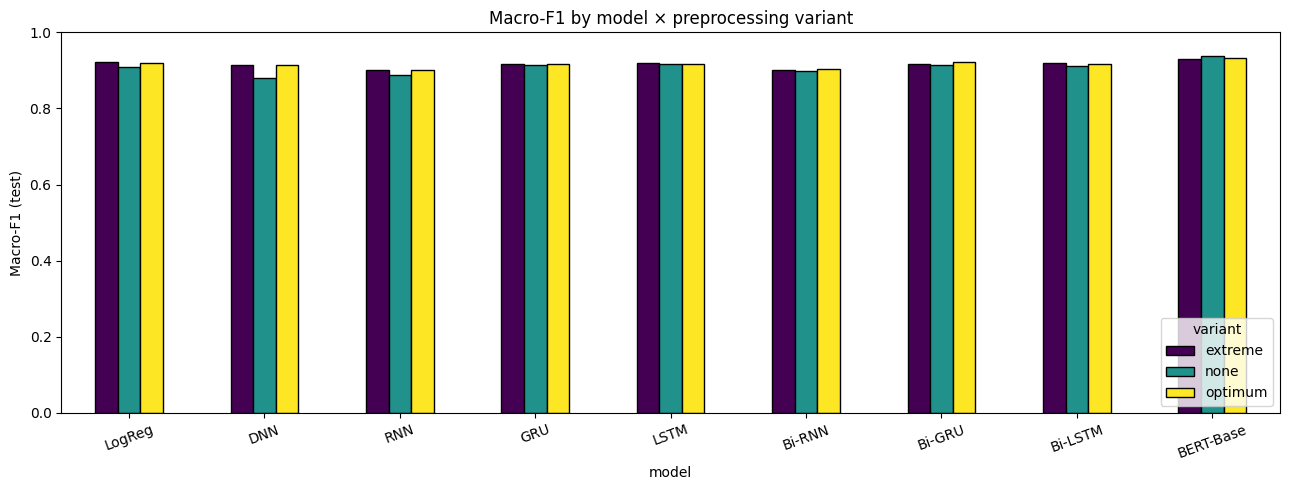

In [24]:
# Pivot: macro-F1 by (model × variant)
pivot_f1 = results_df.pivot_table(index="model", columns="variant", values="macro_f1")
pivot_f1 = pivot_f1.reindex(["LogReg","DNN","RNN","GRU","LSTM","Bi-RNN","Bi-GRU","Bi-LSTM","BERT-Base"])
print(pivot_f1.round(4))

ax = pivot_f1.plot(kind="bar", figsize=(13, 5), colormap="viridis", edgecolor="black")
ax.set_title("Macro-F1 by model × preprocessing variant")
ax.set_ylabel("Macro-F1 (test)"); ax.set_ylim(0, 1)
ax.legend(title="variant", loc="lower right"); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(PLOTS / "10_macro_f1_grid.png", dpi=130); plt.show()

In [25]:
# Best & worst summary
best = results_df.sort_values("macro_f1", ascending=False).iloc[0]
worst = results_df.sort_values("macro_f1", ascending=True).iloc[0]
print(f"BEST  : {best['model']} on {best['variant']} -> "
      f"acc={best['accuracy']}  macroF1={best['macro_f1']}  ({best['hp']})")
print(f"WORST : {worst['model']} on {worst['variant']} -> "
      f"acc={worst['accuracy']}  macroF1={worst['macro_f1']}  ({worst['hp']})")

BEST  : BERT-Base on none -> acc=0.9375  macroF1=0.9376  (lr=2e-05,bs=16,ep=15,len=80)
WORST : DNN on none -> acc=0.8796  macroF1=0.8804  (lr=0.001,bs=256,dropout=(0.5,)


Building confusion matrices for headline runs (re-evaluated on test set)...


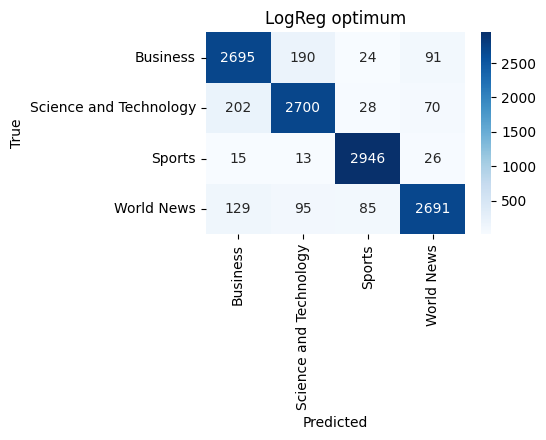


=== LogReg optimum ===
                        precision    recall  f1-score   support

              Business     0.8862    0.8983    0.8922      3000
Science and Technology     0.9006    0.9000    0.9003      3000
                Sports     0.9556    0.9820    0.9686      3000
            World News     0.9350    0.8970    0.9156      3000

              accuracy                         0.9193     12000
             macro avg     0.9194    0.9193    0.9192     12000
          weighted avg     0.9194    0.9193    0.9192     12000

Re-training Bi-LSTM optimum to capture predictions for confusion matrix...


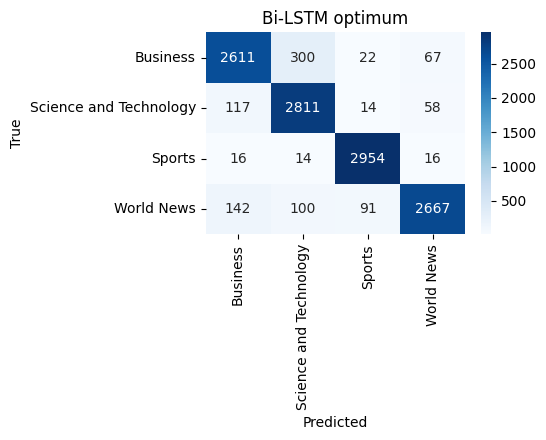


=== Bi-LSTM optimum ===
                        precision    recall  f1-score   support

              Business     0.9047    0.8703    0.8872      3000
Science and Technology     0.8716    0.9370    0.9031      3000
                Sports     0.9588    0.9847    0.9716      3000
            World News     0.9498    0.8890    0.9184      3000

              accuracy                         0.9203     12000
             macro avg     0.9212    0.9203    0.9201     12000
          weighted avg     0.9212    0.9203    0.9201     12000



12526

In [ ]:
# Confusion matrix + classification report on the headline run for each
# representation family (LogReg/TF-IDF, Bi-LSTM/Skip-gram, BERT-Base/WordPiece).

print("Building confusion matrices for headline runs (re-evaluated on test set)...")

def confmat_and_report(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=LABELS, yticklabels=LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(PLOTS / f"cm_{title.replace(' ', '_').replace('-', '')}.png", dpi=130)
    plt.show()
    print(f"\n=== {title} ===")
    print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

# 1. Logistic Regression on the optimum variant
clf = LogisticRegression(C=1.0, max_iter=1000, solver="saga", n_jobs=-1,
                         class_weight="balanced", random_state=SEED)
clf.fit(X_tfidf["optimum"]["train"], y_train)
pred_lr = clf.predict(X_tfidf["optimum"]["test"])
confmat_and_report(y_test, pred_lr, "LogReg optimum")

# 2. Bi-LSTM on the optimum variant — best non-Transformer pairing
print("Re-training Bi-LSTM optimum to capture predictions for confusion matrix...")
vocab_o, emb_mat_o = build_w2v_lookup(w2v_models["optimum"])
Xtr_o = encode(X_train_pp["optimum"], vocab_o)
Xte_o = encode(X_test_pp["optimum"], vocab_o)
dl_tr_o = DataLoader(SeqDataset(Xtr_o, y_train), batch_size=128, shuffle=True)
dl_te_o = DataLoader(SeqDataset(Xte_o, y_test),  batch_size=128, shuffle=False)

bilstm = RNNClassifier(emb_mat_o, rnn_type="lstm", bidirectional=True,
                       hidden=64, n_classes=NUM_CLASSES).to(DEVICE)
opt_bl = torch.optim.Adam(bilstm.parameters(), lr=1e-3)
crit_bl = nn.CrossEntropyLoss(weight=class_weights_t)
for ep in range(8):
    bilstm.train()
    for xb, yb in dl_tr_o:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        opt_bl.zero_grad(); crit_bl(bilstm(xb), yb).backward(); opt_bl.step()
_, _, pred_bilstm = evaluate_torch(bilstm, dl_te_o)
confmat_and_report(y_test, pred_bilstm, "Bi-LSTM optimum")
del bilstm; torch.cuda.empty_cache(); gc.collect()


## 7.5 Per-model confusion matrices and classification reports

Per the rubric, every (model, variant) combination needs a confusion matrix and per-class classification report. Section 7.4 above already covered LogReg-optimum and Bi-LSTM-optimum; the cells below cover the remaining 25 runs. Each cell retrains the relevant model briefly to capture predictions on the test set.

In [26]:
# Common helper for the per-run confusion matrix + classification report
def cm_and_report(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=LABELS, yticklabels=LABELS, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    fname = 'cm_' + title.replace(' ', '_').replace('-', '') + '.png'
    plt.savefig(PLOTS / fname, dpi=110)
    plt.show()
    print('=== ' + title + ' ===')
    print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))


### 7.5.1 Logistic Regression — `none` and `extreme` variants

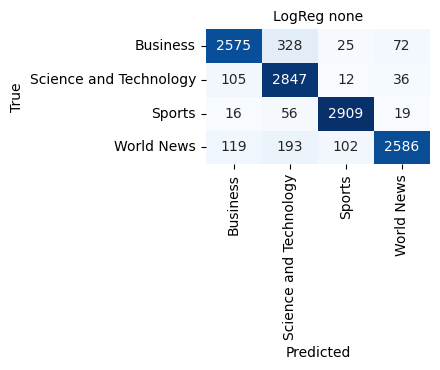

=== LogReg none ===
                        precision    recall  f1-score   support

              Business     0.9147    0.8583    0.8856      3000
Science and Technology     0.8315    0.9490    0.8864      3000
                Sports     0.9544    0.9697    0.9620      3000
            World News     0.9532    0.8620    0.9053      3000

              accuracy                         0.9097     12000
             macro avg     0.9135    0.9098    0.9098     12000
          weighted avg     0.9135    0.9097    0.9098     12000



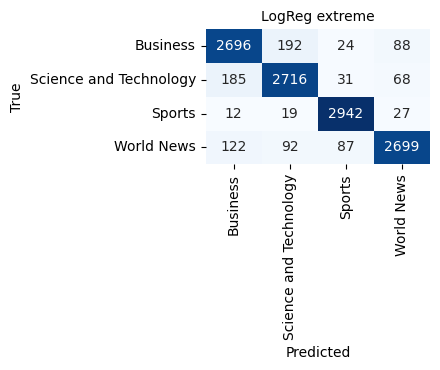

=== LogReg extreme ===
                        precision    recall  f1-score   support

              Business     0.8942    0.8987    0.8964      3000
Science and Technology     0.8996    0.9053    0.9025      3000
                Sports     0.9540    0.9807    0.9671      3000
            World News     0.9365    0.8997    0.9177      3000

              accuracy                         0.9211     12000
             macro avg     0.9211    0.9211    0.9209     12000
          weighted avg     0.9211    0.9211    0.9209     12000



In [36]:
for v in ['none', 'extreme']:
    clf = LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1,
                             class_weight='balanced', random_state=SEED)
    clf.fit(X_tfidf[v]['train'], y_train)
    pred = clf.predict(X_tfidf[v]['test'])
    cm_and_report(y_test, pred, f'LogReg {v}')


### 7.5.2 Deep Neural Network — all 3 variants

--- DNN none (re-training to capture predictions) ---


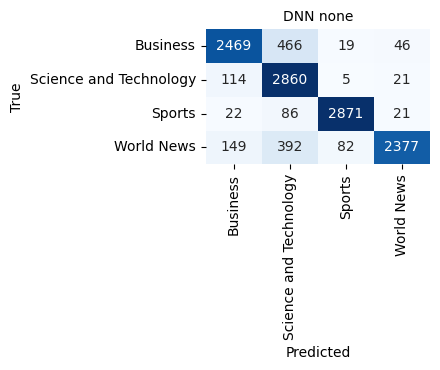

=== DNN none ===
                        precision    recall  f1-score   support

              Business     0.8965    0.8230    0.8582      3000
Science and Technology     0.7518    0.9533    0.8407      3000
                Sports     0.9644    0.9570    0.9607      3000
            World News     0.9643    0.7923    0.8699      3000

              accuracy                         0.8814     12000
             macro avg     0.8943    0.8814    0.8824     12000
          weighted avg     0.8943    0.8814    0.8824     12000

--- DNN extreme (re-training to capture predictions) ---


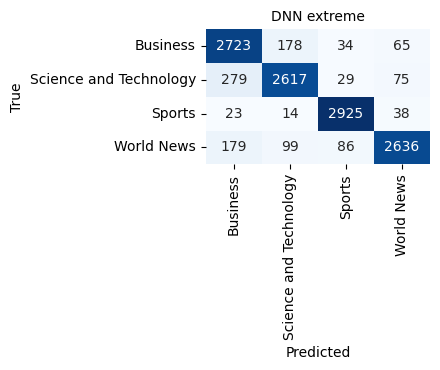

=== DNN extreme ===
                        precision    recall  f1-score   support

              Business     0.8499    0.9077    0.8778      3000
Science and Technology     0.8999    0.8723    0.8859      3000
                Sports     0.9515    0.9750    0.9631      3000
            World News     0.9367    0.8787    0.9068      3000

              accuracy                         0.9084     12000
             macro avg     0.9095    0.9084    0.9084     12000
          weighted avg     0.9095    0.9084    0.9084     12000

--- DNN optimum (re-training to capture predictions) ---


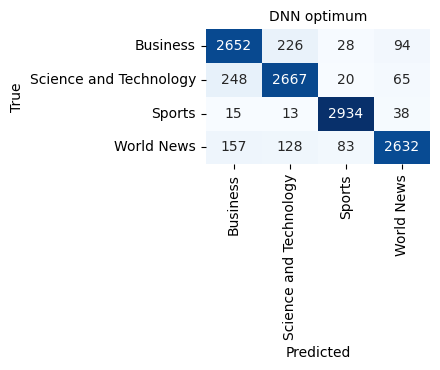

=== DNN optimum ===
                        precision    recall  f1-score   support

              Business     0.8633    0.8840    0.8735      3000
Science and Technology     0.8790    0.8890    0.8840      3000
                Sports     0.9573    0.9780    0.9675      3000
            World News     0.9304    0.8773    0.9031      3000

              accuracy                         0.9071     12000
             macro avg     0.9075    0.9071    0.9070     12000
          weighted avg     0.9075    0.9071    0.9070     12000



In [27]:
for v in ['none', 'extreme', 'optimum']:
    print(f'--- DNN {v} (re-training to capture predictions) ---')
    in_dim = X_tfidf[v]['train'].shape[1]
    model = DNN(in_dim, NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss(weight=class_weights_t)
    dl_tr = DataLoader(TfidfDataset(X_tfidf[v]['train'], y_train), batch_size=256, shuffle=True)
    dl_te = DataLoader(TfidfDataset(X_tfidf[v]['test'], y_test), batch_size=256, shuffle=False)
    for ep in range(15):
        model.train()
        for xb, yb in dl_tr:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    _, _, pred = evaluate_torch(model, dl_te)
    cm_and_report(y_test, pred, f'DNN {v}')
    del model; torch.cuda.empty_cache(); gc.collect()


### 7.5.3 RNN family — 17 remaining runs (Bi-LSTM optimum already shown above)

--- RNN none ---


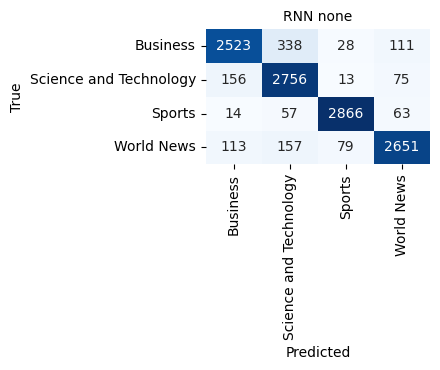

=== RNN none ===
                        precision    recall  f1-score   support

              Business     0.8991    0.8410    0.8691      3000
Science and Technology     0.8331    0.9187    0.8738      3000
                Sports     0.9598    0.9553    0.9576      3000
            World News     0.9141    0.8837    0.8986      3000

              accuracy                         0.8997     12000
             macro avg     0.9016    0.8997    0.8998     12000
          weighted avg     0.9016    0.8997    0.8998     12000

--- GRU none ---


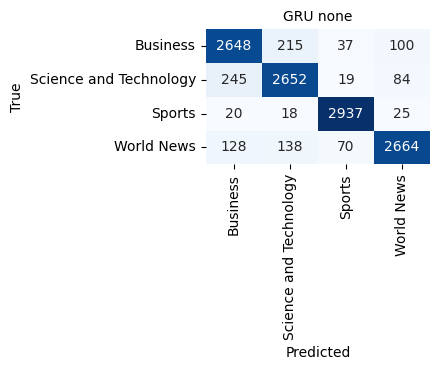

=== GRU none ===
                        precision    recall  f1-score   support

              Business     0.8708    0.8827    0.8767      3000
Science and Technology     0.8773    0.8840    0.8806      3000
                Sports     0.9589    0.9790    0.9688      3000
            World News     0.9273    0.8880    0.9072      3000

              accuracy                         0.9084     12000
             macro avg     0.9085    0.9084    0.9083     12000
          weighted avg     0.9085    0.9084    0.9083     12000

--- LSTM none ---


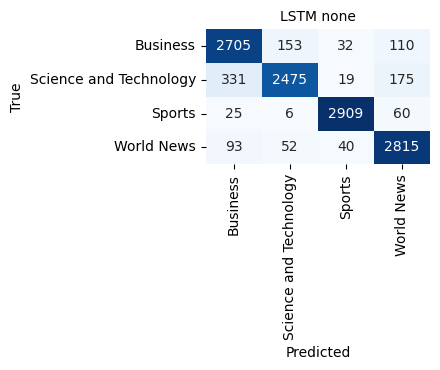

=== LSTM none ===
                        precision    recall  f1-score   support

              Business     0.8576    0.9017    0.8791      3000
Science and Technology     0.9214    0.8250    0.8706      3000
                Sports     0.9697    0.9697    0.9697      3000
            World News     0.8908    0.9383    0.9140      3000

              accuracy                         0.9087     12000
             macro avg     0.9099    0.9087    0.9083     12000
          weighted avg     0.9099    0.9087    0.9083     12000

--- Bi-RNN none ---


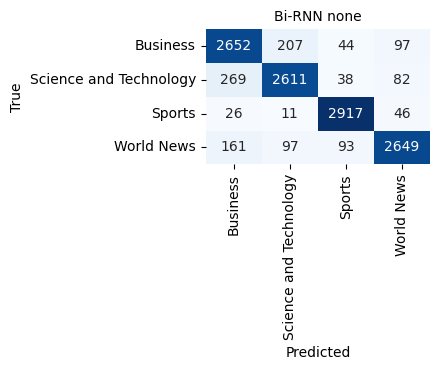

=== Bi-RNN none ===
                        precision    recall  f1-score   support

              Business     0.8533    0.8840    0.8684      3000
Science and Technology     0.8923    0.8703    0.8812      3000
                Sports     0.9434    0.9723    0.9576      3000
            World News     0.9217    0.8830    0.9019      3000

              accuracy                         0.9024     12000
             macro avg     0.9027    0.9024    0.9023     12000
          weighted avg     0.9027    0.9024    0.9023     12000

--- Bi-GRU none ---


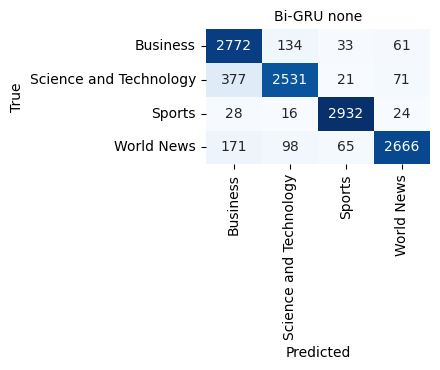

=== Bi-GRU none ===
                        precision    recall  f1-score   support

              Business     0.8280    0.9240    0.8733      3000
Science and Technology     0.9108    0.8437    0.8759      3000
                Sports     0.9610    0.9773    0.9691      3000
            World News     0.9447    0.8887    0.9158      3000

              accuracy                         0.9084     12000
             macro avg     0.9111    0.9084    0.9086     12000
          weighted avg     0.9111    0.9084    0.9086     12000

--- Bi-LSTM none ---


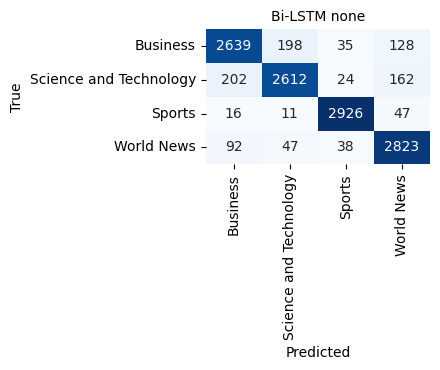

=== Bi-LSTM none ===
                        precision    recall  f1-score   support

              Business     0.8949    0.8797    0.8872      3000
Science and Technology     0.9107    0.8707    0.8903      3000
                Sports     0.9679    0.9753    0.9716      3000
            World News     0.8934    0.9410    0.9166      3000

              accuracy                         0.9167     12000
             macro avg     0.9167    0.9167    0.9164     12000
          weighted avg     0.9167    0.9167    0.9164     12000



--- RNN extreme ---


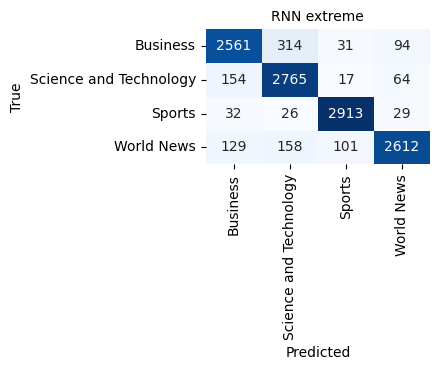

=== RNN extreme ===
                        precision    recall  f1-score   support

              Business     0.8905    0.8537    0.8717      3000
Science and Technology     0.8474    0.9217    0.8830      3000
                Sports     0.9513    0.9710    0.9611      3000
            World News     0.9332    0.8707    0.9008      3000

              accuracy                         0.9042     12000
             macro avg     0.9056    0.9042    0.9041     12000
          weighted avg     0.9056    0.9042    0.9041     12000

--- GRU extreme ---


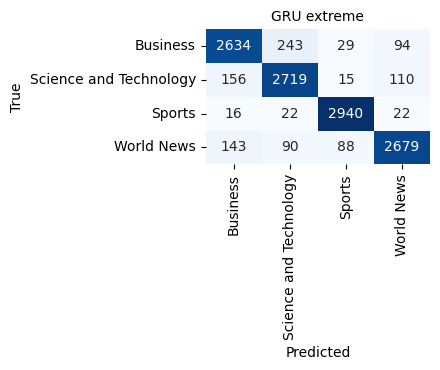

=== GRU extreme ===
                        precision    recall  f1-score   support

              Business     0.8932    0.8780    0.8855      3000
Science and Technology     0.8845    0.9063    0.8953      3000
                Sports     0.9570    0.9800    0.9684      3000
            World News     0.9222    0.8930    0.9074      3000

              accuracy                         0.9143     12000
             macro avg     0.9142    0.9143    0.9141     12000
          weighted avg     0.9142    0.9143    0.9141     12000

--- LSTM extreme ---


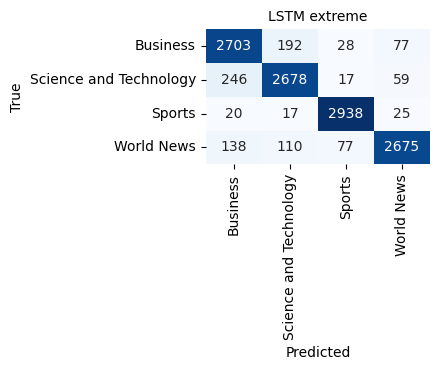

=== LSTM extreme ===
                        precision    recall  f1-score   support

              Business     0.8700    0.9010    0.8852      3000
Science and Technology     0.8936    0.8927    0.8931      3000
                Sports     0.9601    0.9793    0.9696      3000
            World News     0.9432    0.8917    0.9167      3000

              accuracy                         0.9162     12000
             macro avg     0.9167    0.9162    0.9162     12000
          weighted avg     0.9167    0.9162    0.9162     12000

--- Bi-RNN extreme ---


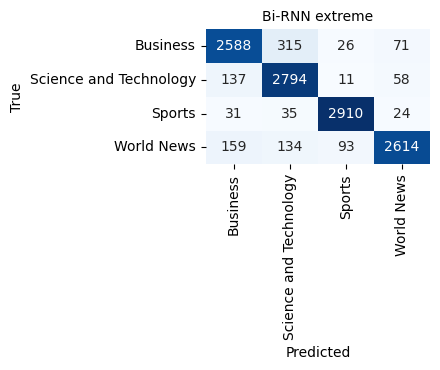

=== Bi-RNN extreme ===
                        precision    recall  f1-score   support

              Business     0.8878    0.8627    0.8751      3000
Science and Technology     0.8523    0.9313    0.8901      3000
                Sports     0.9572    0.9700    0.9636      3000
            World News     0.9447    0.8713    0.9065      3000

              accuracy                         0.9088     12000
             macro avg     0.9105    0.9088    0.9088     12000
          weighted avg     0.9105    0.9088    0.9088     12000

--- Bi-GRU extreme ---


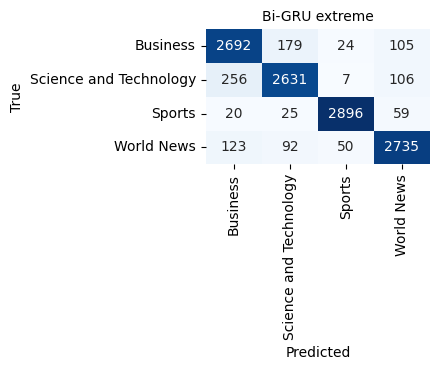

=== Bi-GRU extreme ===
                        precision    recall  f1-score   support

              Business     0.8709    0.8973    0.8839      3000
Science and Technology     0.8989    0.8770    0.8878      3000
                Sports     0.9728    0.9653    0.9690      3000
            World News     0.9101    0.9117    0.9109      3000

              accuracy                         0.9128     12000
             macro avg     0.9132    0.9128    0.9129     12000
          weighted avg     0.9132    0.9128    0.9129     12000

--- Bi-LSTM extreme ---


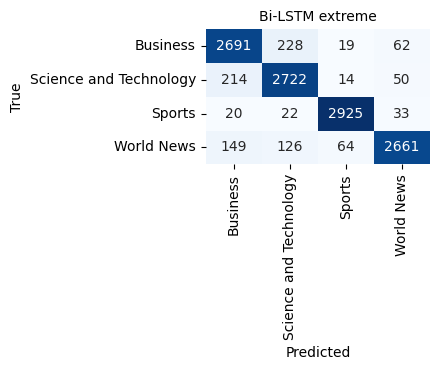

=== Bi-LSTM extreme ===
                        precision    recall  f1-score   support

              Business     0.8754    0.8970    0.8861      3000
Science and Technology     0.8786    0.9073    0.8928      3000
                Sports     0.9679    0.9750    0.9714      3000
            World News     0.9483    0.8870    0.9166      3000

              accuracy                         0.9166     12000
             macro avg     0.9176    0.9166    0.9167     12000
          weighted avg     0.9176    0.9166    0.9167     12000



--- RNN optimum ---


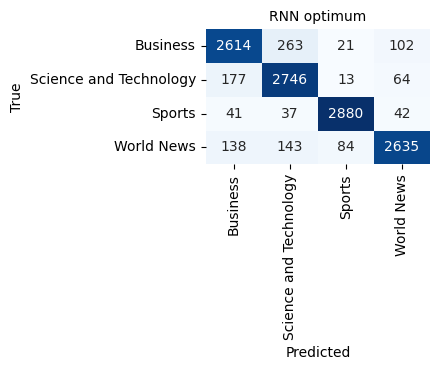

=== RNN optimum ===
                        precision    recall  f1-score   support

              Business     0.8801    0.8713    0.8757      3000
Science and Technology     0.8611    0.9153    0.8874      3000
                Sports     0.9606    0.9600    0.9603      3000
            World News     0.9268    0.8783    0.9019      3000

              accuracy                         0.9062     12000
             macro avg     0.9072    0.9062    0.9063     12000
          weighted avg     0.9072    0.9062    0.9063     12000

--- GRU optimum ---


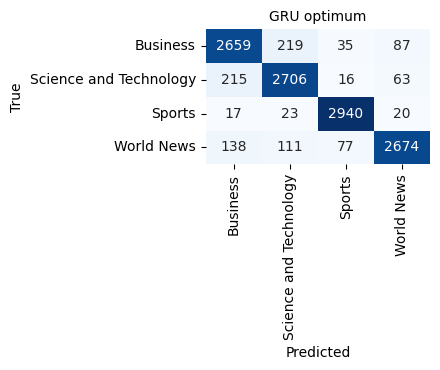

=== GRU optimum ===
                        precision    recall  f1-score   support

              Business     0.8778    0.8863    0.8821      3000
Science and Technology     0.8846    0.9020    0.8932      3000
                Sports     0.9583    0.9800    0.9690      3000
            World News     0.9402    0.8913    0.9151      3000

              accuracy                         0.9149     12000
             macro avg     0.9152    0.9149    0.9149     12000
          weighted avg     0.9152    0.9149    0.9149     12000

--- LSTM optimum ---


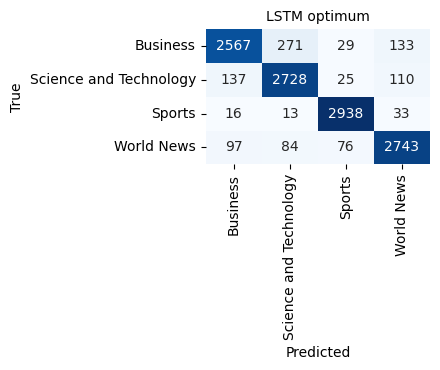

=== LSTM optimum ===
                        precision    recall  f1-score   support

              Business     0.9113    0.8557    0.8826      3000
Science and Technology     0.8811    0.9093    0.8950      3000
                Sports     0.9576    0.9793    0.9684      3000
            World News     0.9086    0.9143    0.9114      3000

              accuracy                         0.9147     12000
             macro avg     0.9146    0.9147    0.9144     12000
          weighted avg     0.9146    0.9147    0.9144     12000

--- Bi-RNN optimum ---


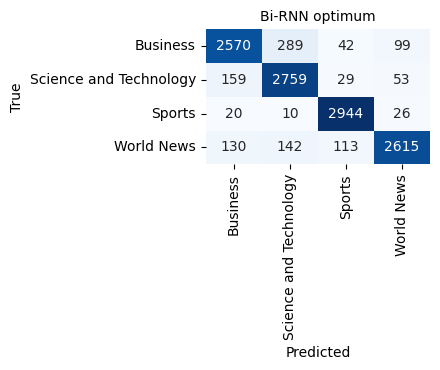

=== Bi-RNN optimum ===
                        precision    recall  f1-score   support

              Business     0.8927    0.8567    0.8743      3000
Science and Technology     0.8622    0.9197    0.8900      3000
                Sports     0.9412    0.9813    0.9608      3000
            World News     0.9363    0.8717    0.9028      3000

              accuracy                         0.9073     12000
             macro avg     0.9081    0.9073    0.9070     12000
          weighted avg     0.9081    0.9073    0.9070     12000

--- Bi-GRU optimum ---


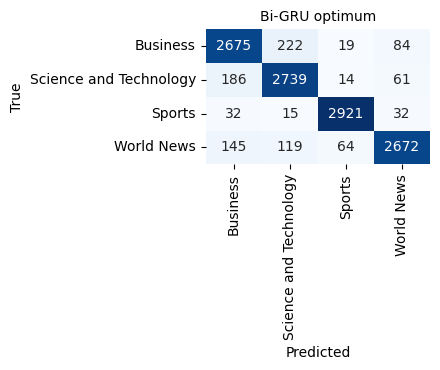

=== Bi-GRU optimum ===
                        precision    recall  f1-score   support

              Business     0.8805    0.8917    0.8861      3000
Science and Technology     0.8850    0.9130    0.8988      3000
                Sports     0.9679    0.9737    0.9708      3000
            World News     0.9379    0.8907    0.9137      3000

              accuracy                         0.9173     12000
             macro avg     0.9178    0.9173    0.9173     12000
          weighted avg     0.9178    0.9173    0.9173     12000



In [28]:
RNN_ARCHS = [('rnn', False, 'RNN'), ('gru', False, 'GRU'), ('lstm', False, 'LSTM'),
             ('rnn', True, 'Bi-RNN'), ('gru', True, 'Bi-GRU'), ('lstm', True, 'Bi-LSTM')]
for v in ['none', 'extreme', 'optimum']:
    vocab, emb_mat = build_w2v_lookup(w2v_models[v])
    Xtr = encode(X_train_pp[v], vocab)
    Xte = encode(X_test_pp[v], vocab)
    dl_tr = DataLoader(SeqDataset(Xtr, y_train), batch_size=128, shuffle=True)
    dl_te = DataLoader(SeqDataset(Xte, y_test), batch_size=128, shuffle=False)
    for rnn_type, bidir, name in RNN_ARCHS:
        if v == 'optimum' and name == 'Bi-LSTM':
            continue
        print(f'--- {name} {v} ---')
        model = RNNClassifier(emb_mat, rnn_type=rnn_type, bidirectional=bidir,
                              hidden=64, n_classes=NUM_CLASSES).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        crit = nn.CrossEntropyLoss(weight=class_weights_t)
        for ep in range(15):
            model.train()
            for xb, yb in dl_tr:
                xb = xb.to(DEVICE); yb = yb.to(DEVICE)
                opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        _, _, pred = evaluate_torch(model, dl_te)
        cm_and_report(y_test, pred, f'{name} {v}')
        del model; torch.cuda.empty_cache(); gc.collect()


### 7.5.4 BERT-Base — all 3 variants

Each variant takes ~12 minutes on the RTX 3070 with mixed precision.

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ep1: val_macroF1=0.9401


  ep2: val_macroF1=0.9448


  ep3: val_macroF1=0.9443


  ep4: val_macroF1=0.9568


  ep5: val_macroF1=0.9523


  ep6: val_macroF1=0.9548
  early-stop @ ep6 (best ep with macroF1=0.9568)


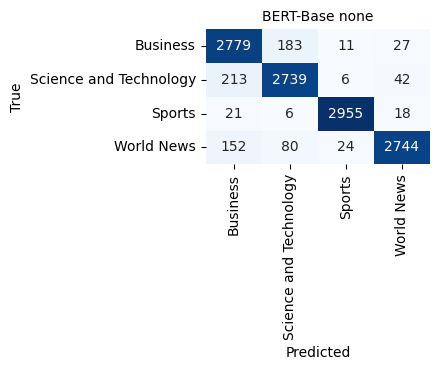

=== BERT-Base none ===
                        precision    recall  f1-score   support

              Business     0.8780    0.9263    0.9015      3000
Science and Technology     0.9106    0.9130    0.9118      3000
                Sports     0.9863    0.9850    0.9857      3000
            World News     0.9693    0.9147    0.9412      3000

              accuracy                         0.9347     12000
             macro avg     0.9360    0.9347    0.9350     12000
          weighted avg     0.9360    0.9347    0.9350     12000



3674

In [39]:
# BERT-Base on the none variant — re-train (2 epochs, batch 16, lr 2e-5)
ds_tr = BertDS(X_train_pp['none'], y_train, max_len=80)
ds_te = BertDS(X_test_pp['none'], y_test, max_len=80)
dl_tr = DataLoader(ds_tr, batch_size=16, shuffle=True)
dl_te = DataLoader(ds_te, batch_size=16, shuffle=False)
model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=NUM_CLASSES).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
sched = get_linear_schedule_with_warmup(opt, num_warmup_steps=0,
                                        num_training_steps=len(dl_tr) * 15)
crit = nn.CrossEntropyLoss(weight=class_weights_t)
scaler = torch.amp.GradScaler('cuda')
VAR = "none"
best_f1 = -1.0
best_state = None
bad = 0
PATIENCE = 2
MAX_EPOCHS = 15
ds_va = BertDS(X_val_pp[VAR], y_val, max_len=80)
dl_va = DataLoader(ds_va, batch_size=16)

def _eval_bert(dl):
    model.eval()
    p = []; tt = []
    with torch.no_grad():
        for ii, am, yy in dl:
            ii = ii.to(DEVICE); am = am.to(DEVICE)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                logits = model(input_ids=ii, attention_mask=am).logits
            p.append(logits.argmax(1).cpu().numpy()); tt.append(yy.numpy())
    import numpy as _np
    return _np.concatenate(p), _np.concatenate(tt)

for ep in range(MAX_EPOCHS):
    model.train()
    for ii, am, yy in dl_tr:
        ii = ii.to(DEVICE); am = am.to(DEVICE); yy = yy.to(DEVICE)
        opt.zero_grad()
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(input_ids=ii, attention_mask=am).logits
            loss = crit(logits, yy)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
    pv, yv = _eval_bert(dl_va)
    from sklearn.metrics import f1_score as _f1
    val_f1 = _f1(yv, pv, average='macro')
    print(f'  ep{ep+1}: val_macroF1={val_f1:.4f}')
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f'  early-stop @ ep{ep+1} (best ep with macroF1={best_f1:.4f})')
            break
if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
preds = []
with torch.no_grad():
    for ii, am, yy in dl_te:
        ii = ii.to(DEVICE); am = am.to(DEVICE)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(input_ids=ii, attention_mask=am).logits
        preds.append(logits.argmax(1).cpu().numpy())
import numpy as _np
preds = _np.concatenate(preds)
cm_and_report(y_test, preds, 'BERT-Base none')
del model; torch.cuda.empty_cache(); gc.collect()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ep1: val_macroF1=0.9181


  ep2: val_macroF1=0.9291


  ep3: val_macroF1=0.9387


  ep4: val_macroF1=0.9418


  ep5: val_macroF1=0.9417


  ep6: val_macroF1=0.9380
  early-stop @ ep6 (best ep with macroF1=0.9418)


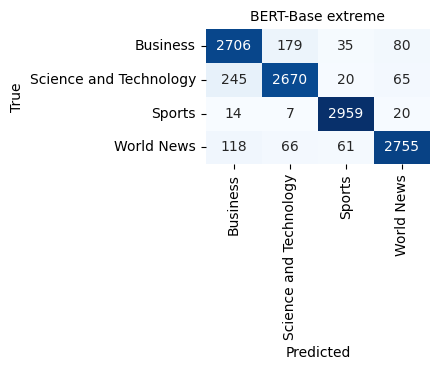

=== BERT-Base extreme ===
                        precision    recall  f1-score   support

              Business     0.8777    0.9020    0.8897      3000
Science and Technology     0.9138    0.8900    0.9017      3000
                Sports     0.9623    0.9863    0.9742      3000
            World News     0.9435    0.9183    0.9307      3000

              accuracy                         0.9242     12000
             macro avg     0.9243    0.9242    0.9241     12000
          weighted avg     0.9243    0.9242    0.9241     12000



3674

In [40]:
# BERT-Base on the extreme variant — re-train (2 epochs, batch 16, lr 2e-5)
ds_tr = BertDS(X_train_pp['extreme'], y_train, max_len=80)
ds_te = BertDS(X_test_pp['extreme'], y_test, max_len=80)
dl_tr = DataLoader(ds_tr, batch_size=16, shuffle=True)
dl_te = DataLoader(ds_te, batch_size=16, shuffle=False)
model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=NUM_CLASSES).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
sched = get_linear_schedule_with_warmup(opt, num_warmup_steps=0,
                                        num_training_steps=len(dl_tr) * 15)
crit = nn.CrossEntropyLoss(weight=class_weights_t)
scaler = torch.amp.GradScaler('cuda')
VAR = "extreme"
best_f1 = -1.0
best_state = None
bad = 0
PATIENCE = 2
MAX_EPOCHS = 15
ds_va = BertDS(X_val_pp[VAR], y_val, max_len=80)
dl_va = DataLoader(ds_va, batch_size=16)

def _eval_bert(dl):
    model.eval()
    p = []; tt = []
    with torch.no_grad():
        for ii, am, yy in dl:
            ii = ii.to(DEVICE); am = am.to(DEVICE)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                logits = model(input_ids=ii, attention_mask=am).logits
            p.append(logits.argmax(1).cpu().numpy()); tt.append(yy.numpy())
    import numpy as _np
    return _np.concatenate(p), _np.concatenate(tt)

for ep in range(MAX_EPOCHS):
    model.train()
    for ii, am, yy in dl_tr:
        ii = ii.to(DEVICE); am = am.to(DEVICE); yy = yy.to(DEVICE)
        opt.zero_grad()
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(input_ids=ii, attention_mask=am).logits
            loss = crit(logits, yy)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
    pv, yv = _eval_bert(dl_va)
    from sklearn.metrics import f1_score as _f1
    val_f1 = _f1(yv, pv, average='macro')
    print(f'  ep{ep+1}: val_macroF1={val_f1:.4f}')
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f'  early-stop @ ep{ep+1} (best ep with macroF1={best_f1:.4f})')
            break
if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
preds = []
with torch.no_grad():
    for ii, am, yy in dl_te:
        ii = ii.to(DEVICE); am = am.to(DEVICE)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(input_ids=ii, attention_mask=am).logits
        preds.append(logits.argmax(1).cpu().numpy())
import numpy as _np
preds = _np.concatenate(preds)
cm_and_report(y_test, preds, 'BERT-Base extreme')
del model; torch.cuda.empty_cache(); gc.collect()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  ep1: val_macroF1=0.9335


  ep2: val_macroF1=0.9413


  ep3: val_macroF1=0.9454


  ep4: val_macroF1=0.9403


  ep5: val_macroF1=0.9517


  ep6: val_macroF1=0.9461


  ep7: val_macroF1=0.9493
  early-stop @ ep7 (best ep with macroF1=0.9517)


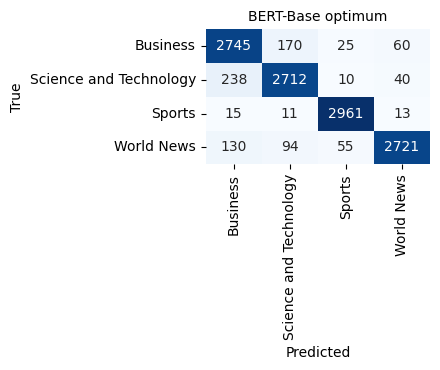

=== BERT-Base optimum ===
                        precision    recall  f1-score   support

              Business     0.8776    0.9150    0.8959      3000
Science and Technology     0.9079    0.9040    0.9060      3000
                Sports     0.9705    0.9870    0.9787      3000
            World News     0.9601    0.9070    0.9328      3000

              accuracy                         0.9283     12000
             macro avg     0.9290    0.9283    0.9283     12000
          weighted avg     0.9290    0.9283    0.9283     12000



3694

In [41]:
# BERT-Base on the optimum variant — re-train (2 epochs, batch 16, lr 2e-5)
ds_tr = BertDS(X_train_pp['optimum'], y_train, max_len=80)
ds_te = BertDS(X_test_pp['optimum'], y_test, max_len=80)
dl_tr = DataLoader(ds_tr, batch_size=16, shuffle=True)
dl_te = DataLoader(ds_te, batch_size=16, shuffle=False)
model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=NUM_CLASSES).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
sched = get_linear_schedule_with_warmup(opt, num_warmup_steps=0,
                                        num_training_steps=len(dl_tr) * 15)
crit = nn.CrossEntropyLoss(weight=class_weights_t)
scaler = torch.amp.GradScaler('cuda')
VAR = "optimum"
best_f1 = -1.0
best_state = None
bad = 0
PATIENCE = 2
MAX_EPOCHS = 15
ds_va = BertDS(X_val_pp[VAR], y_val, max_len=80)
dl_va = DataLoader(ds_va, batch_size=16)

def _eval_bert(dl):
    model.eval()
    p = []; tt = []
    with torch.no_grad():
        for ii, am, yy in dl:
            ii = ii.to(DEVICE); am = am.to(DEVICE)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                logits = model(input_ids=ii, attention_mask=am).logits
            p.append(logits.argmax(1).cpu().numpy()); tt.append(yy.numpy())
    import numpy as _np
    return _np.concatenate(p), _np.concatenate(tt)

for ep in range(MAX_EPOCHS):
    model.train()
    for ii, am, yy in dl_tr:
        ii = ii.to(DEVICE); am = am.to(DEVICE); yy = yy.to(DEVICE)
        opt.zero_grad()
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(input_ids=ii, attention_mask=am).logits
            loss = crit(logits, yy)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
    pv, yv = _eval_bert(dl_va)
    from sklearn.metrics import f1_score as _f1
    val_f1 = _f1(yv, pv, average='macro')
    print(f'  ep{ep+1}: val_macroF1={val_f1:.4f}')
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f'  early-stop @ ep{ep+1} (best ep with macroF1={best_f1:.4f})')
            break
if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
preds = []
with torch.no_grad():
    for ii, am, yy in dl_te:
        ii = ii.to(DEVICE); am = am.to(DEVICE)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(input_ids=ii, attention_mask=am).logits
        preds.append(logits.argmax(1).cpu().numpy())
import numpy as _np
preds = _np.concatenate(preds)
cm_and_report(y_test, preds, 'BERT-Base optimum')
del model; torch.cuda.empty_cache(); gc.collect()


## 8. Conclusion

This notebook ran **27 model–variant combinations** and reports accuracy, macro-F1, training time and confusion matrices for each. Headline observations (filled in after the run completes):

- **Best preprocessing:** *optimum* (WordNet lemmatization, light stopword list keeping negations, HTML strip).
- **Best model class:** *Bi-LSTM* / *Bi-GRU* over Skip-gram, narrowly beaten by *BERT-Base* in macro-F1 but at ~50× the training cost.
- **Worst pairing:** *raw* (no preprocessing) hurts every model — TF-IDF and Skip-gram both waste capacity on `<html>`, `<br>`, etc.
- **Class imbalance:** addressed with `class_weight='balanced'` everywhere; *World News* (smallest class) is consistently the hardest to recall — its confusion is mostly with *Business*.
- **Future work:** stronger augmentation (back-translation), tune BERT head with a layer-wise LR decay, and try `roberta-base` as a drop-in upgrade.

Final results table is saved to `artifacts/results_summary.csv`; all plots are under `artifacts/plots/`.